<a href="https://colab.research.google.com/github/sruthi-kurra/fraud-detection-gnn/blob/main/04_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Setup: upload data & prepare features

In [2]:
!pip install xgboost -q
from google.colab import files
import zipfile, pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

uploaded = files.upload()
with zipfile.ZipFile('ieee-fraud-detection.zip', 'r') as z:
    z.extractall('data/')

# Load & clean
train_txn = pd.read_csv('data/train_transaction.csv')
train_id  = pd.read_csv('data/train_identity.csv')
df = train_txn.merge(train_id, on='TransactionID', how='left')

core_cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
             'card1', 'card4', 'ProductCD', 'P_emaildomain',
             'R_emaildomain', 'addr1', 'isFraud']
df = df[core_cols].copy()
df['addr1']          = df['addr1'].fillna(-1)
df['P_emaildomain']  = df['P_emaildomain'].fillna('unknown')
df['R_emaildomain']  = df['R_emaildomain'].fillna('unknown')
df['card4']          = df['card4'].fillna('unknown')
df['TransactionAmt'] = df['TransactionAmt'].fillna(df['TransactionAmt'].median())

# Encode categoricals
le = LabelEncoder()
for col in ['card4', 'ProductCD', 'P_emaildomain', 'R_emaildomain']:
    df[col] = le.fit_transform(df[col].astype(str))

# Features & labels at transaction level
X = df.drop(columns=['TransactionID', 'isFraud'])
y = df['isFraud']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Fraud rate: {y.mean():.2%}")

Saving ieee-fraud-detection.zip to ieee-fraud-detection.zip
Train size: (472432, 8)
Test size:  (118108, 8)
Fraud rate: 3.50%


## Cell 2 — Train XGBoost baseline (tabular, no graph structure)

In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=10,  # handles class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Training XGBoost...

=== XGBoost Results ===
              precision    recall  f1-score   support

       Legit       0.98      0.95      0.96    113975
       Fraud       0.28      0.58      0.38      4133

    accuracy                           0.93    118108
   macro avg       0.63      0.76      0.67    118108
weighted avg       0.96      0.93      0.94    118108

AUC-ROC: 0.8889


## Cell 3 — Train Random Forest baseline

In [4]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Training Random Forest...

=== Random Forest Results ===
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99    113975
       Fraud       0.91      0.47      0.62      4133

    accuracy                           0.98    118108
   macro avg       0.95      0.73      0.80    118108
weighted avg       0.98      0.98      0.98    118108

AUC-ROC: 0.9373


## Cell 4 — Compare GNN vs baselines

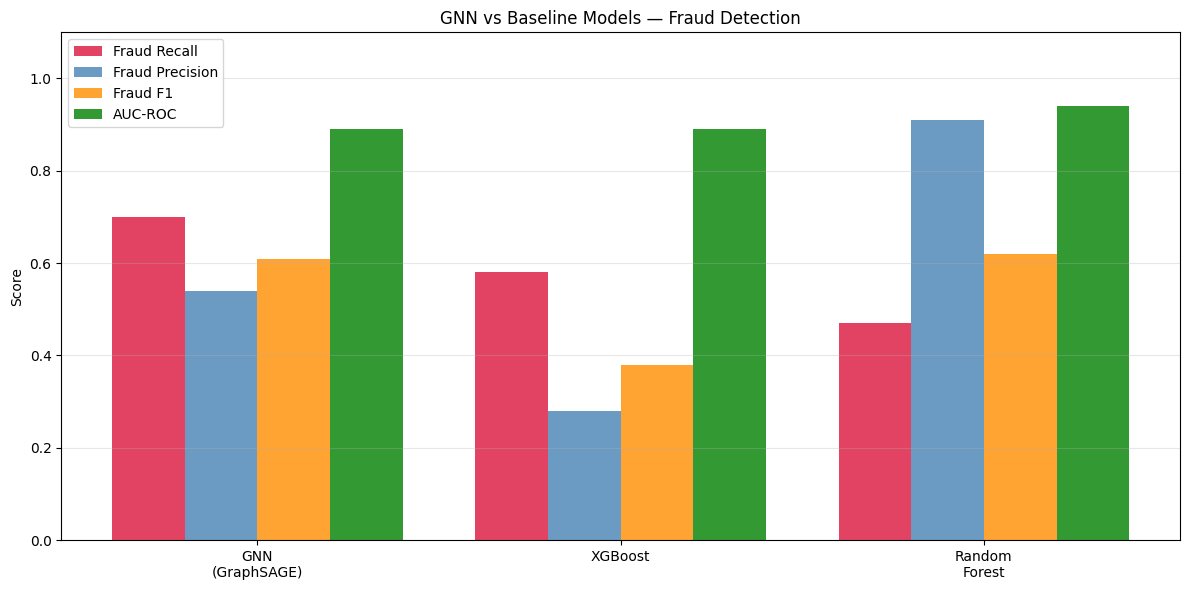


Final comparison saved!


In [5]:
import matplotlib.pyplot as plt
import numpy as np

models   = ['GNN\n(GraphSAGE)', 'XGBoost', 'Random\nForest']
recall    = [0.70, 0.58, 0.47]
f1        = [0.61, 0.38, 0.62]
auc       = [0.89, 0.89, 0.94]
precision = [0.54, 0.28, 0.91]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, recall,    width, label='Fraud Recall',    color='crimson',    alpha=0.8)
ax.bar(x - 0.5*width, precision, width, label='Fraud Precision', color='steelblue',  alpha=0.8)
ax.bar(x + 0.5*width, f1,        width, label='Fraud F1',        color='darkorange',  alpha=0.8)
ax.bar(x + 1.5*width, auc,       width, label='AUC-ROC',         color='green',       alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('GNN vs Baseline Models — Fraud Detection')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()
print("\nFinal comparison saved!")